# Modeling: Rank Fusion Committee

Run after `feature_selection.ipynb`. Outputs → `outputs/rank_fusion/`.

## Flow
1. `setup_modeling_notebook` — data + paths
2. Train diverse experts → weighted OOF fusion
3. OOF profit curve → export


In [ ]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
from cost_effective.models import experts_summary_frame
from cost_effective.notebook_setup import setup_modeling_notebook
from cost_effective.notebook_workflows import (
    evaluate_topk_oof,
    export_fusion_test_predictions,
    run_rank_fusion_pipeline,
    stage_matrices,
)
from cost_effective.paths import APPROACH_RANK_FUSION
from cost_effective.plots import plot_topk_oof_profit_curve

In [3]:
ctx = setup_modeling_notebook(APPROACH_RANK_FUSION)
_, y_train, x_test, x_stage2 = stage_matrices(ctx)
ctx.stage.stage3_scores.head()

,feature_set_name,feature_count,cv_score_mean,cv_score_std,f1_score,roc_auc_score,business_score_no_var_penalty,features
0,top_01,1,2301.0,24.779023,0.667868,0.547226,2501.0,[var_389]
1,top_03,3,1891.0,32.155870,0.666970,0.550985,2491.0,"[var_389, var_308, var_93]"
2,top_05,5,1490.0,23.874673,0.666908,0.589741,2490.0,"[var_389, var_308, var_93, var_87, var_254]"
3,top_08,8,898.0,30.757113,0.667579,0.583463,2498.0,"[var_389, var_308, var_93, var_87, var_254, va..."
4,top_10,10,486.0,17.146428,0.666538,0.616666,2486.0,"[var_389, var_308, var_93, var_87, var_254, va..."


In [4]:
fusion = run_rank_fusion_pipeline(ctx)
experts_df = experts_summary_frame(fusion)
experts_df.to_csv(ctx.outputs_path / "fusion_experts.csv", index=False)
experts_df

,expert,model,feature_set,n_features,cv_business_mean,cv_business_std,fusion_weight
0,logistic_top03,logistic_regression,top_03,3,1905.0,22.135944,0.330442
1,lightgbm_top05,lightgbm,top_05,5,1490.0,23.874673,0.258456
3,borda_top05,borda_rank,top_05,5,1467.0,154.259522,0.254467
2,logistic_top08,logistic_regression,top_08,8,903.0,30.099834,0.156635


In [5]:
oof_eval = evaluate_topk_oof(
    y_train,
    fusion.fused_oof_probabilities,
    fusion.feature_count,
    ctx.max_targets,
)
for line in oof_eval.summary_lines:
    print(line)
oof_eval.confusion_matrix

Business-optimal: k=994, threshold=0.5321, score=2085.00
F1-optimal: k=1000, threshold=0.5319, f1=0.3320, roc_auc=0.5559, avg_precision=0.5606
Business curve TP=577, FP=417
F1 curve TP=579, FP=421
OOF profit-optimal k=994, break-even k=1000, effective k=994


,Predicted 0,Predicted 1
Actual 0,2095,417
Actual 1,1911,577


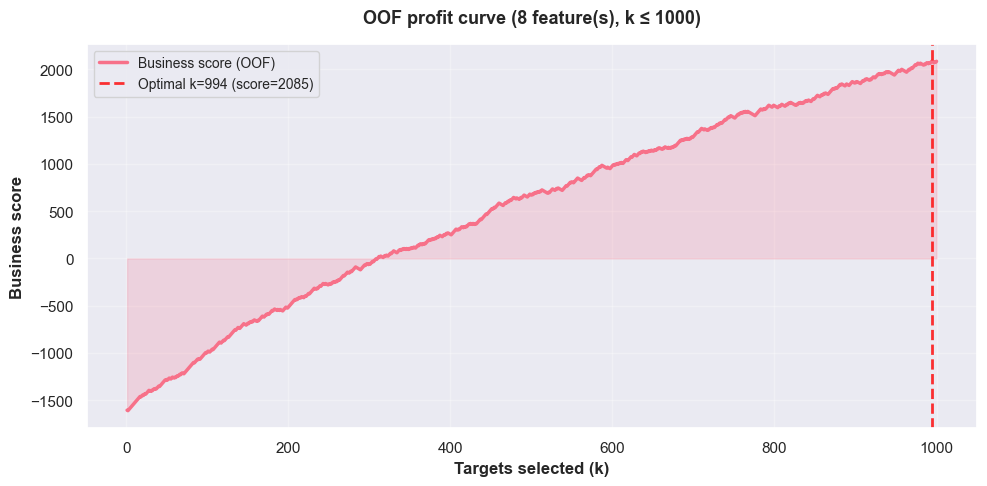

In [6]:
plot_topk_oof_profit_curve(
    oof_eval.business_curve,
    fusion.feature_count,
    ctx.max_targets,
).show()

In [7]:
predictions = export_fusion_test_predictions(ctx, fusion, x_stage2, y_train, x_test, oof_eval)
predictions.head()

,rank,sample_index,probability
0,1,4928,0.729313
1,2,2916,0.710605
2,3,588,0.705777
3,4,4134,0.698767
4,5,2855,0.693550
